# Rootzone Soft-Sensor V8 - EC Slope Replacement - Variant E (Salt/Irrigation Ratio) - 48h Holdout

Same as Variant E (salt/irrigation ratio features) but evaluated on a 48h holdout horizon
matching the setup in Continuous_Rootzone_V8_48h.ipynb.

**Features replacing `prev_ec_slope`:**
- `pre_salt_irr_ratio_6h`  = decay_weighted_salt_6h  / (irrigation_6h  + 1)
- `pre_salt_irr_ratio_24h` = decay_weighted_salt_24h / (irrigation_24h + 1)

**Holdout:** 48h horizon, 11 explicit anchors, SKIP_MAX_GAP_H=48h

26h holdout baseline (Variant E):  EC MAE 0.1920  R2 0.9322
26h original baseline:             EC MAE 0.1902  R2 0.9355

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import HuberRegressor
import matplotlib.pyplot as plt

# ==========================================
# 1. Data Loading & Helper Functions
# ==========================================
df = pd.read_csv('master.csv', parse_dates=['timestamp'])
df = df.sort_values('timestamp').set_index('timestamp')
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors='coerce')
master_df = df.copy().sort_index()

n_ph = int(master_df['ph'].notna().sum()) if 'ph' in master_df.columns else 0
n_ec = int(master_df['ec_ms'].notna().sum()) if 'ec_ms' in master_df.columns else 0
n_both = int((master_df['ph'].notna() & master_df['ec_ms'].notna()).sum()) if {'ph','ec_ms'}.issubset(master_df.columns) else 0

print(f'Loaded: {len(df)} rows')
print(f'Labeled samples -> pH: {n_ph}, EC: {n_ec}, both: {n_both}')

ACID_FERTS = ['Phosphoric acid[mg]-H3PO4']
SALT_FERTS = ['Monopotassium Phosphate[mg] -KH2PO4', 'Potassium Chloride[mg] - KCL',
              'Kortin [mg]', 'Ammonium Nitrate [mg] -NH4NO3', 'Gypsum - CaSO4*2H2O [mg]']
CORE_SALT_FERTS = ['Monopotassium Phosphate[mg] -KH2PO4', 'Potassium Chloride[mg] - KCL',
                   'Ammonium Nitrate [mg] -NH4NO3']

def _to_num(s, d=0.0): return pd.to_numeric(s, errors='coerce').fillna(d)

def _sum_avail(fr, cols):
    u = [c for c in cols if c in fr.columns]
    return float(fr[u].apply(pd.to_numeric, errors='coerce').fillna(0).sum().sum()) if u else 0.0

def _sum_avail_series(fr, cols):
    u = [c for c in cols if c in fr.columns]
    return fr[u].apply(pd.to_numeric, errors='coerce').fillna(0).sum(axis=1) if u else pd.Series(0.0, index=fr.index)

def _get_fert_any(fr):
    if 'fertilization_flag' in fr.columns: return _to_num(fr['fertilization_flag'])
    a = 'fertilization_type_a_flag' in fr.columns
    b = 'fertilization_type_b_flag' in fr.columns
    if a or b:
        fa = _to_num(fr['fertilization_type_a_flag']) if a else pd.Series(0., index=fr.index)
        fb = _to_num(fr['fertilization_type_b_flag']) if b else pd.Series(0., index=fr.index)
        return ((fa > 0) | (fb > 0)).astype(float)
    return pd.Series(0., index=fr.index)


Loaded: 16682 rows
Labeled samples -> pH: 109, EC: 109, both: 109


In [2]:
# ==========================================
# 2. Feature Extraction (final model inputs)
# ==========================================
# This cell only computes features used by the final shared model plus the
# small helper fields needed for training weights and the robust linear gate.

def _segment(master_df, start, stop):
    if pd.Timestamp(start) >= pd.Timestamp(stop):
        return master_df.iloc[0:0]
    return master_df.loc[(master_df.index >= pd.Timestamp(start)) & (master_df.index < pd.Timestamp(stop))]


def get_window_features(master_df, anchor_idx, current_idx):
    t0 = pd.Timestamp(anchor_idx)
    t1 = pd.Timestamp(current_idx)
    ph0 = float(master_df.loc[t0, 'ph'])
    ec0 = float(master_df.loc[t0, 'ec_ms'])
    gap_h = float((t1 - t0).total_seconds() / 3600.0)
    safe_gap_h = max(gap_h, 0.16)
    seg = _segment(master_df, t0, t1)

    irr_s = _to_num(seg['irrigation_ml_current']) if 'irrigation_ml_current' in seg.columns else pd.Series(0.0, index=seg.index)
    irr_total = float(irr_s.sum()) if len(seg) else 0.0
    fert_salt_total = _sum_avail(seg, SALT_FERTS)
    h3po4_total = _sum_avail(seg, ACID_FERTS)

    ET0_sum = float(_to_num(seg['ET0']).sum()) if 'ET0' in seg.columns else 0.0
    ET0_per_hour = float(ET0_sum / safe_gap_h)
    salt_conc_t0_t1 = float(fert_salt_total / (irr_total + 1.0))
    irr_to_et0 = float(irr_total / (ET0_sum + 0.1))

    if 'internal_air_temp_c' in seg.columns and 'internal_rh_%' in seg.columns and len(seg) > 0:
        temp_s = _to_num(seg['internal_air_temp_c'])
        rh_s = _to_num(seg['internal_rh_%'])
        es_s = 0.6108 * np.exp((17.27 * temp_s) / (temp_s + 237.3))
        vpd_mean = float((es_s * (1.0 - rh_s / 100.0)).mean())
    else:
        temp_s = pd.Series(dtype=float)
        vpd_mean = 0.0

    soil_temp_mean = float(_to_num(seg['soil_temp_pred']).mean()) if 'soil_temp_pred' in seg.columns and len(seg) > 0 else 0.0
    canopy = float(_to_num(seg['canopy_cover']).mean()) if 'canopy_cover' in seg.columns and len(seg) > 0 else 0.0
    transpiration_pull = float(vpd_mean * canopy)
    photo_temp_interaction = float(vpd_mean * soil_temp_mean)
    temp_x_canopy = float(soil_temp_mean * canopy)
    temp_trend = float(temp_s.iloc[-1] - temp_s.iloc[0]) if len(temp_s) > 1 else 0.0

    rad_s = _to_num(seg['internal_radiation']) if 'internal_radiation' in seg.columns else pd.Series(dtype=float)
    rad_morning = (
        float(_to_num(seg.loc[(seg.index.hour >= 6) & (seg.index.hour < 12), 'internal_radiation']).sum())
        if len(seg) > 0 and 'internal_radiation' in seg.columns
        else 0.0
    )

    fert_any = _get_fert_any(seg) if len(seg) > 0 else pd.Series(dtype=float)
    fert_times = fert_any[fert_any > 0].index
    hrs_since_fert = float((t1 - fert_times.max()).total_seconds() / 3600.0) if len(fert_times) > 0 else gap_h

    core_salt_s = _sum_avail_series(seg, CORE_SALT_FERTS) if len(seg) > 0 else pd.Series(0.0, index=seg.index)
    salt_event_idx = core_salt_s[core_salt_s > 0].index.max() if len(core_salt_s[core_salt_s > 0]) else None
    last_salt_dose = float(core_salt_s.loc[salt_event_idx]) if salt_event_idx is not None else 0.0
    last_irr_amount = float(irr_s.loc[salt_event_idx]) if salt_event_idx is not None and salt_event_idx in irr_s.index else 0.0
    hrs_since_last_salt_event = float((t1 - salt_event_idx).total_seconds() / 3600.0) if salt_event_idx is not None else gap_h
    last_event_salt_conc = float(last_salt_dose / (last_irr_amount + 1.0))
    irr_after_last_salt = (
        float(_to_num(seg.loc[seg.index > salt_event_idx, 'irrigation_ml_current']).sum())
        if salt_event_idx is not None and 'irrigation_ml_current' in seg.columns
        else 0.0
    )

    hour_b = t1.hour + t1.minute / 60.0
    days_after_planting_t1 = float(master_df.loc[t1, 'days_after_planting']) if 'days_after_planting' in master_df.columns else 0.0

    t1_soil = (
        _to_num(master_df.loc[t1:t1, 'soil_temp_pred']).iloc[0]
        if t1 in master_df.index and master_df.loc[t1, 'soil_temp_pred'] != 0
        else float(_to_num(seg['soil_temp_pred']).iloc[-1]) if len(seg) > 0 and 'soil_temp_pred' in seg.columns else 0.0
    )
    t0_soil = float(_to_num(master_df.loc[t0:t0, 'soil_temp_pred']).iloc[0]) if 'soil_temp_pred' in master_df.columns else 0.0
    rad_t1 = (
        float(_to_num(master_df.loc[t1:t1, 'internal_radiation']).iloc[0])
        if t1 in master_df.index and 'internal_radiation' in master_df.columns
        else 0.0
    )

    return {
        'ph0': ph0,
        'ec0': ec0,
        'gap_hours': gap_h,
        'irr_total_t0_t1': irr_total,
        'fert_salt_total_t0_t1': fert_salt_total,
        'ET0_sum_t0_t1': ET0_sum,
        'ET0_per_hour': ET0_per_hour,
        'h3po4_total': h3po4_total,
        'log_ec_drive': float(np.log((fert_salt_total + h3po4_total) / (irr_total + 1.0) + 0.01) - np.log(ec0 + 0.01)),
        'soil_temp_mean': soil_temp_mean,
        'transpiration_pull': transpiration_pull,
        'photo_temp_interaction': photo_temp_interaction,
        'temp_x_canopy': temp_x_canopy,
        'salt_conc_t0_t1': salt_conc_t0_t1,
        'irr_to_et0': irr_to_et0,
        'stage_x_salt_conc': float((days_after_planting_t1 / 100.0) * salt_conc_t0_t1),
        'ec_log_anchor': float(np.log(ec0 + 0.05)),
        'hrs_since_fert': hrs_since_fert,
        'hrs_since_last_salt_event': hrs_since_last_salt_event,
        'last_event_salt_conc': last_event_salt_conc,
        'irr_after_last_salt': irr_after_last_salt,
        'temp_trend': temp_trend,
        'hour_sin_b': float(np.sin(2 * np.pi * hour_b / 24.0)),
        'hour_cos_b': float(np.cos(2 * np.pi * hour_b / 24.0)),
        't1_morning_short': int((5 <= t1.hour <= 10) and (gap_h <= 1.5)),
        't1_early_day': int(5 <= hour_b < 13.0),
        'soil_delta': float(t1_soil - t0_soil),
        'rad_t1_log': float(np.log1p(rad_t1)),
        'rad_morning': rad_morning,
    }


def get_history_features(master_df, t0, t1):
    t1 = pd.Timestamp(t1)

    recent_6h = _segment(master_df, t1 - pd.Timedelta(hours=6), t1)
    prior_12_24h = _segment(master_df, t1 - pd.Timedelta(hours=24), t1 - pd.Timedelta(hours=12))
    hist24 = _segment(master_df, t1 - pd.Timedelta(hours=24), t1)

    def _irr(seg):
        return float(_to_num(seg['irrigation_ml_current']).sum()) if 'irrigation_ml_current' in seg.columns and len(seg) > 0 else 0.0

    hist_irr_recent = _irr(recent_6h)
    hist_irr_prior = _irr(prior_12_24h)
    hist_dark_recent_6h = (
        float((_to_num(recent_6h['internal_radiation']) <= 10).sum()) / 6.0
        if 'internal_radiation' in recent_6h.columns and len(recent_6h) > 0
        else 0.0
    )

    hist_acid_decay = 0.0
    if len(hist24) > 0:
        acid_doses = _sum_avail_series(hist24, ACID_FERTS)
        acid_mask = acid_doses > 0
        if acid_mask.any():
            hrs_before_t1 = np.array((t1 - hist24.index[acid_mask]).total_seconds()) / 3600.0
            hist_acid_decay = float((acid_doses[acid_mask].values * np.exp(-0.34 * hrs_before_t1)).sum())

    if len(hist24) > 1:
        hist_irr_s = _to_num(hist24['irrigation_ml_current']) if 'irrigation_ml_current' in hist24.columns else pd.Series(0.0, index=hist24.index)
        salt_s = _sum_avail_series(hist24, SALT_FERTS)
        salt_mask = salt_s > 0
        if salt_mask.any():
            hrs_before_t1 = np.array((t1 - hist24.index[salt_mask]).total_seconds()) / 3600.0
            decayed_salt = float((salt_s[salt_mask].values * np.exp(-0.15 * hrs_before_t1)).sum())
        else:
            decayed_salt = 0.0
        hist_salt_buildup = float(decayed_salt - float(hist_irr_s.sum()) * 0.1)

        fert_any = _get_fert_any(hist24)
        fert_times = hist24.index[fert_any > 0]
        hist_hrs_since_fert = float((t1 - fert_times[-1]).total_seconds() / 3600.0) if len(fert_times) > 0 else 24.0
    else:
        hist_salt_buildup = 0.0
        hist_hrs_since_fert = 24.0

    return {
        'hist_irr_recent': hist_irr_recent,
        'hist_irr_prior': hist_irr_prior,
        'hist_dark_recent_6h': hist_dark_recent_6h,
        'hist_acid_decay': hist_acid_decay,
        'hist_salt_buildup': hist_salt_buildup,
        'hist_hrs_since_fert': hist_hrs_since_fert,
    }


def get_target_prevday_features(master_df, t1):
    t1 = pd.Timestamp(t1)
    prevday = _segment(master_df, t1 - pd.Timedelta(hours=48), t1 - pd.Timedelta(hours=24))
    return {
        'hist48_irr_prevday': (
            float(_to_num(prevday['irrigation_ml_current']).sum())
            if 'irrigation_ml_current' in prevday.columns and len(prevday) > 0
            else 0.0
        )
    }




def get_features_shared(master_df, anchor_idx, current_idx):
    feats = {
        **get_window_features(master_df, anchor_idx, current_idx),
        **get_history_features(master_df, t0=anchor_idx, t1=current_idx),
        **get_target_prevday_features(master_df, t1=current_idx),
    }

    t0 = pd.Timestamp(anchor_idx)
    t1 = pd.Timestamp(current_idx)

    # Pre-anchor helpers: irrigation and decay-weighted salt before the anchor (no labeled EC needed)
    def _pre_irr(seg):
        return float(_to_num(seg['irrigation_ml_current']).sum()) \
            if 'irrigation_ml_current' in seg.columns and len(seg) > 0 else 0.0

    def _pre_salt_dw(seg, t_ref):
        if len(seg) == 0:
            return 0.0
        salt_cols = [c for c in SALT_FERTS if c in seg.columns]
        if not salt_cols:
            return 0.0
        s = seg[salt_cols].apply(pd.to_numeric, errors='coerce').fillna(0).sum(axis=1)
        sm = s > 0
        if not sm.any():
            return 0.0
        hrs_ago = np.array((pd.Timestamp(t_ref) - seg.index[sm]).total_seconds()) / 3600.0
        return float((s[sm].values * np.exp(-0.15 * hrs_ago)).sum())

    pre6h_seg  = _segment(master_df, t0 - pd.Timedelta(hours=6),  t0)
    pre24h_seg = _segment(master_df, t0 - pd.Timedelta(hours=24), t0)
    irr_6h   = _pre_irr(pre6h_seg)
    irr_24h  = _pre_irr(pre24h_seg)
    salt_6h  = _pre_salt_dw(pre6h_seg,  t0)
    salt_24h = _pre_salt_dw(pre24h_seg, t0)

    # Variant E: salt/irrigation ratio before anchor
    # High ratio  -> salt was concentrating -> EC trending up
    # Low ratio   -> irrigation was diluting -> EC trending down
    pre_salt_irr_ratio_6h  = float(salt_6h  / (irr_6h  + 1.0))
    pre_salt_irr_ratio_24h = float(salt_24h / (irr_24h + 1.0))

    gap_h_safe = max(float(feats['gap_hours']), 0.25)
    hist48_pre_t0 = _segment(master_df, t0 - pd.Timedelta(hours=48), t0)
    salt48_pre_t0 = float(_sum_avail(hist48_pre_t0, SALT_FERTS)) if len(hist48_pre_t0) > 0 else 0.0

    feats.update({
        'pre_salt_irr_ratio_6h':  pre_salt_irr_ratio_6h,
        'pre_salt_irr_ratio_24h': pre_salt_irr_ratio_24h,
        'salt_recency_pressure': float(feats['last_event_salt_conc'] * np.exp(-feats['hrs_since_last_salt_event'] / 6.0)),
        'salt_event_pos': float(np.clip(1.0 - (feats['hrs_since_last_salt_event'] / gap_h_safe), 0.0, 1.0)),
        'ec0_x_p48_salt': float(feats['ec0'] * salt48_pre_t0),
    })
    return feats

## Holdout Schedule

Reserved skip-pairs used for long-horizon validation. These rows are excluded from skip-row training.

In [3]:
# Holdout set — 48h horizon (longer intervals than the 26h default).
# Consecutive intervals stay in training.
# Only skip intervals starting from selected anchors are reserved for holdout.
# ==========================================
EVAL_WINDOW_H = 48.0
DEFAULT_HOLDOUT_START_POS = 61
DEFAULT_HOLDOUT_ANCHOR_PATTERN = (0, 1)
EXPLICIT_HOLDOUT_ANCHORS = [6, 10, 15, 25, 59, 61, 68, 76, 86, 95, 102]
# Rare-event anchors keep only a representative subset in holdout.
# The skipped intervals outside these are released back to training.
HOLDOUT_SKIP_KEEP_IDX_BY_ANCHOR = {
    95: (0, 1, 3, 4),  # keep 10:30, 12:00, 14:10, 15:10; release 13:10
    102: (0, 3, 4),    # keep 08:40, 13:40, 15:30; release 10:30, 11:40
}
HOLDOUT_SKIP_SLICE_BY_ANCHOR = {}
SKIP_MAX_GAP_H = 48.0
EC_TARGET_SHIFT = 0.005


def select_anchor_skip_targets(anchor_pos, skip_targets, keep_idx_by_anchor=None, skip_slice_by_anchor=None):
    if keep_idx_by_anchor and anchor_pos in keep_idx_by_anchor:
        keep_idx = tuple(int(i) for i in keep_idx_by_anchor[anchor_pos])
        return [skip_targets[i] for i in keep_idx if 0 <= i < len(skip_targets)]
    if not skip_slice_by_anchor:
        return skip_targets
    skip_slice = skip_slice_by_anchor.get(anchor_pos)
    if skip_slice is None:
        return skip_targets
    start, stop = skip_slice
    return skip_targets[start:stop]


def count_anchor_skip_targets(sensor_idx, anchor_positions, horizon_hours=48.0):
    counts = {}
    N = len(sensor_idx)
    for pos in anchor_positions:
        t0 = sensor_idx[pos]
        n_skip_targets = 0
        for k in range(pos + 2, N):
            gap_h = (sensor_idx[k] - t0).total_seconds() / 3600.0
            if gap_h > horizon_hours:
                break
            n_skip_targets += 1
        counts[pos] = n_skip_targets
    return counts


def build_skip_holdout_schedule(sensor_idx, start_pos=0, horizon_hours=48.0,
                                anchor_step_pattern=(0,), explicit_anchor_positions=None,
                                keep_idx_by_anchor=None, skip_slice_by_anchor=None):
    pattern = tuple(anchor_step_pattern)
    anchors = []
    holdout_pairs = []
    N = len(sensor_idx)

    if explicit_anchor_positions:
        positions = sorted(set(int(pos) for pos in explicit_anchor_positions if 0 <= int(pos) < N - 1))
    else:
        positions = []
        pos = int(start_pos)
        step_i = 0
        while pos < N - 1:
            positions.append(pos)
            step = pattern[step_i % len(pattern)] if pattern else 0
            step_i += 1
            pos = max(pos + int(step) + 1, pos + 1)

    for pos in positions:
        t0 = sensor_idx[pos]
        window_targets = []
        for k in range(pos + 1, N):
            gap_h = (sensor_idx[k] - t0).total_seconds() / 3600.0
            if gap_h > horizon_hours:
                break
            window_targets.append((k, gap_h))

        skip_targets = [(k, gap_h) for k, gap_h in window_targets if k >= pos + 2]
        skip_targets = select_anchor_skip_targets(pos, skip_targets, keep_idx_by_anchor, skip_slice_by_anchor)
        if not skip_targets:
            continue

        anchors.append({
            'anchor_pos': pos,
            'anchor_time': t0,
            'window_end_pos': window_targets[-1][0],
            'window_end_time': sensor_idx[window_targets[-1][0]],
            'n_skip_targets': len(skip_targets),
        })
        holdout_pairs.extend((pos, k, gap_h) for k, gap_h in skip_targets)

    return anchors, holdout_pairs


_sensor_idx_all = list(master_df.index[master_df['ph'].notna() & master_df['ec_ms'].notna()])
HOLDOUT_ANCHORS, HOLDOUT_SKIP_PAIRS_WITH_GAP = build_skip_holdout_schedule(
    _sensor_idx_all,
    start_pos=DEFAULT_HOLDOUT_START_POS,
    horizon_hours=EVAL_WINDOW_H,
    anchor_step_pattern=DEFAULT_HOLDOUT_ANCHOR_PATTERN,
    explicit_anchor_positions=EXPLICIT_HOLDOUT_ANCHORS,
    keep_idx_by_anchor=HOLDOUT_SKIP_KEEP_IDX_BY_ANCHOR,
    skip_slice_by_anchor=HOLDOUT_SKIP_SLICE_BY_ANCHOR,
)
HOLDOUT_SKIP_PAIRS = {(j, k) for j, k, _ in HOLDOUT_SKIP_PAIRS_WITH_GAP}
HOLDOUT_SKIP_COUNTS_BY_ANCHOR = count_anchor_skip_targets(
    _sensor_idx_all,
    [a['anchor_pos'] for a in HOLDOUT_ANCHORS],
    horizon_hours=EVAL_WINDOW_H,
)

print(f'Holdout anchors: {len(HOLDOUT_ANCHORS)}')
print(f'Holdout skip pairs: {len(HOLDOUT_SKIP_PAIRS_WITH_GAP)}')
print(f'Holdout config -> explicit anchors={EXPLICIT_HOLDOUT_ANCHORS}, '
      f'horizon={EVAL_WINDOW_H}h, skip_cap={SKIP_MAX_GAP_H}h, '
      f'keep_idx={HOLDOUT_SKIP_KEEP_IDX_BY_ANCHOR}, skip_slices={HOLDOUT_SKIP_SLICE_BY_ANCHOR}')
released_summary = [
    f"pos={a['anchor_pos']} released={HOLDOUT_SKIP_COUNTS_BY_ANCHOR.get(a['anchor_pos'], a['n_skip_targets']) - a['n_skip_targets']} kept={a['n_skip_targets']}"
    for a in HOLDOUT_ANCHORS
    if HOLDOUT_SKIP_COUNTS_BY_ANCHOR.get(a['anchor_pos'], a['n_skip_targets']) > a['n_skip_targets']
]
if released_summary:
    print('Released skip intervals back to training:')
    print('  ' + ' | '.join(released_summary))

if HOLDOUT_ANCHORS:
    preview = ', '.join(f"{a['anchor_time']:%Y-%m-%d %H:%M}" for a in HOLDOUT_ANCHORS[:5])
    print(f'Anchor preview: {preview}')


Holdout anchors: 11
Holdout skip pairs: 44
Holdout config -> explicit anchors=[6, 10, 15, 25, 59, 61, 68, 76, 86, 95, 102], horizon=48.0h, skip_cap=48.0h, keep_idx={95: (0, 1, 3, 4), 102: (0, 3, 4)}, skip_slices={}
Released skip intervals back to training:
  pos=95 released=1 kept=4 | pos=102 released=2 kept=3
Anchor preview: 2025-07-23 17:30, 2025-07-28 09:00, 2025-08-03 09:00, 2025-08-10 08:20, 2025-09-07 15:30


## Shared Unified Model

This cell defines the final shared feature set, shared XGBoost base model, shared robust linear component, and walk-forward training loop.

In [4]:
from sklearn.multioutput import MultiOutputRegressor
import warnings

SHARED_EVAL_START_DATE = pd.Timestamp('2025-09-01')
SHARED_SKIP_MAX_GAP_H = 48.0
SHARED_MAX_SKIP_ROWS = 4
SHARED_SCALE_TARGETS = False
ROBUST_LINEAR_MIN_ROWS = 8
SHARED_SHOCK_WEIGHT = 16.0
ROBUST_LINEAR_BLEND = 1.00
ROBUST_LINEAR_BLEND_PH = ROBUST_LINEAR_BLEND
ROBUST_LINEAR_BLEND_EC = ROBUST_LINEAR_BLEND
ROBUST_LINEAR_GATE_MAX_GAP_H = 12.0

shared_xgb_params = {
    'n_estimators': 1000,
    'learning_rate': 0.033,
    'max_depth': 4,
    'min_child_weight': 2,
    'subsample': 0.75,
    'colsample_bytree': 0.55,
    'colsample_bynode': 0.65,
    'reg_alpha': 2.5,
    'reg_lambda': 3.5,
    'random_state': 42,
    'n_jobs': -1,
    'tree_method': 'hist',
    'objective': 'reg:squarederror',
    'gamma': 0.02,
}

robust_linear_params = {
    'alpha': 0.001,
    'epsilon': 3.0,
    'max_iter': 10000,
    'tol': 1e-5,
}

def _unique(seq):
    out = []
    for item in seq:
        if item not in out:
            out.append(item)
    return out

# Final shared feature set selected by shared pH/EC feature analysis.
# Keeps common climate, irrigation, fertilizer, EC memory, and salt timing drivers.
shared_feature_cols = [
    'ph0',
    'ec0',
    'gap_hours',
    'ET0_per_hour',
    'transpiration_pull',
    'photo_temp_interaction',
    'temp_x_canopy',
    't1_early_day',
    't1_morning_short',
    'soil_delta',
    'rad_t1_log',
    'hist_dark_recent_6h',
    'rad_morning',
    'hist_irr_recent',
    'hist_irr_prior',
    'hist_salt_buildup',
    'hist_hrs_since_fert',
    'hist48_irr_prevday',
    'stage_x_salt_conc',
    'log_ec_drive',
    'soil_temp_mean',
    'ec_log_anchor',
    'salt_conc_t0_t1',
    'irr_to_et0',
    'temp_trend',
    'pre_salt_irr_ratio_6h',
    'pre_salt_irr_ratio_24h',
    'irr_total_t0_t1',
    'hour_cos_b',
    'hour_sin_b',
    'salt_recency_pressure',
    'hrs_since_fert',
    'irr_after_last_salt',
    'salt_event_pos',
    'ec0_x_p48_salt',
    'fert_salt_total_t0_t1',
    'ET0_sum_t0_t1',
]
sensor_idx = list(master_df.index[master_df['ph'].notna() & master_df['ec_ms'].notna()])
SHARED_WARMUP = next(i for i, ts in enumerate(sensor_idx) if ts >= SHARED_EVAL_START_DATE)
SHARED_LAST_WARMUP_TIMESTAMP = sensor_idx[SHARED_WARMUP - 1]
SHARED_FIRST_EVAL_TIMESTAMP = sensor_idx[SHARED_WARMUP]

print(f'Joint labeled timestamps: {len(sensor_idx)}')
print(f'Unified model features: {len(shared_feature_cols)}')
print('Balanced-importance XGBoost: stronger regularization, lower column sampling, and a small split-gain threshold')
print('Shared split rule: train through 2025-08-31, evaluate from September onward')
print(f'Shared warmup position: {SHARED_WARMUP}')
print(f'Last warmup timestamp: {SHARED_LAST_WARMUP_TIMESTAMP}')
print(f'First evaluation timestamp: {SHARED_FIRST_EVAL_TIMESTAMP}')

def _selected_shared_skip_pairs(k):
    selected = []
    for back in range(2, k + 1):
        j = k - back
        gap_h = (pd.Timestamp(sensor_idx[k]) - pd.Timestamp(sensor_idx[j])).total_seconds() / 3600.0
        if gap_h > SHARED_SKIP_MAX_GAP_H:
            break
        if (j, k) in HOLDOUT_SKIP_PAIRS:
            continue
        selected.append((j, k, back, gap_h))
        if SHARED_MAX_SKIP_ROWS is not None and len(selected) >= SHARED_MAX_SKIP_ROWS:
            break
    return selected

def _make_shared_row(j, k, timestamp=None):
    t1 = sensor_idx[k]
    row = get_features_shared(master_df, sensor_idx[j], t1)
    row['ph_true'] = float(master_df.loc[t1, 'ph'])
    row['ec_true'] = float(master_df.loc[t1, 'ec_ms'])
    row['timestamp'] = t1 if timestamp is None else timestamp
    return row

def _build_shared_rows(up_to_pos):
    rows = []
    for k in range(1, up_to_pos + 1):
        rows.append(_make_shared_row(k - 1, k))
        for j, _, back, _ in _selected_shared_skip_pairs(k):
            rows.append(_make_shared_row(j, k, sensor_idx[k] + pd.Timedelta(microseconds=back)))
    return rows

def _shared_targets(train_df):
    ph_delta = (train_df['ph_true'] - train_df['ph0']).to_numpy()
    ec_log_delta = np.log(
        (train_df['ec_true'].to_numpy() + EC_TARGET_SHIFT) /
        (train_df['ec0'].to_numpy() + EC_TARGET_SHIFT)
    )
    return np.column_stack([ph_delta, ec_log_delta])

def _robust_linear_training_mask(train_df):
    salt_event = (train_df['fert_salt_total_t0_t1'] >= 250.0) & (train_df['irr_after_last_salt'] <= 1.0)
    acid_event = (train_df['h3po4_total'] > 0.0) | (train_df['hist_acid_decay'] > 0.002)
    return (salt_event | acid_event).to_numpy()

def _shared_shock_mask(train_df):
    return (
        (train_df['fert_salt_total_t0_t1'] >= 250.0) &
        (train_df['irr_after_last_salt'] <= 1.0) &
        (train_df['salt_conc_t0_t1'] >= 3.0) &
        (train_df['ec0'] <= 0.8)
    ).to_numpy()

def _robust_linear_weights(train_df, robust_mask):
    weights = np.ones(int(robust_mask.sum()))
    shock_mask = _shared_shock_mask(train_df)[robust_mask]
    weights += SHARED_SHOCK_WEIGHT * shock_mask.astype(float)
    return weights

def _robust_linear_gate(feats):
    return bool(
        feats.get('fert_salt_total_t0_t1', 0.0) >= 250.0 and
        feats.get('irr_after_last_salt', 0.0) <= 1.0 and
        feats.get('salt_conc_t0_t1', 0.0) >= 3.0 and
        feats.get('ec0', np.inf) <= 0.8 and
        feats.get('gap_hours', np.inf) <= ROBUST_LINEAR_GATE_MAX_GAP_H
    )



def _shared_base_weights(train_df):
    """Shared weights emphasize rare EC movement/flush rows and pH jumps."""
    ec_log_delta = np.abs(_shared_targets(train_df)[:, 1])
    ph_delta = np.abs(train_df['ph_true'].to_numpy() - train_df['ph0'].to_numpy())

    irr_q75 = float(train_df['irr_total_t0_t1'].quantile(0.75))
    salt_conc_q35 = float(train_df['salt_conc_t0_t1'].quantile(0.35))
    ec_move_q80 = float(pd.Series(ec_log_delta).quantile(0.80))
    ph_move_q80 = float(pd.Series(ph_delta).quantile(0.80))

    flush = (
        (train_df['ec0'].to_numpy() >= 1.0)
        & (train_df['irr_total_t0_t1'].to_numpy() >= irr_q75)
        & (train_df['salt_conc_t0_t1'].to_numpy() <= salt_conc_q35)
        & (train_df['gap_hours'].to_numpy() >= 6.0)
    )
    ec_movement = ec_log_delta >= max(ec_move_q80, 0.35)
    ph_movement = ph_delta >= max(ph_move_q80, 0.75)
    salt_shock = _shared_shock_mask(train_df)

    weights = (
        1.0
        + 2.0 * flush.astype(float)
        + 1.0 * ec_movement.astype(float)
        + 1.5 * salt_shock.astype(float)
        + 1.0 * ph_movement.astype(float)
    )
    return np.clip(weights, 1.0, 5.5)


def _fit_shared_model(train_df):
    X = train_df[shared_feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    Y = _shared_targets(train_df)
    y_mean = np.zeros(2)
    y_std = np.ones(2)
    if SHARED_SCALE_TARGETS:
        y_mean = Y.mean(axis=0)
        y_std = Y.std(axis=0)
        y_std = np.where(y_std < 1e-9, 1.0, y_std)
        Y_fit = (Y - y_mean) / y_std
    else:
        Y_fit = Y

    base = xgb.XGBRegressor(**shared_xgb_params)
    base.fit(X, Y_fit, sample_weight=_shared_base_weights(train_df), verbose=False)

    robust_mask = _robust_linear_training_mask(train_df)
    robust_linear = None
    if int(robust_mask.sum()) >= ROBUST_LINEAR_MIN_ROWS:
        robust_linear = make_pipeline(
            StandardScaler(),
            MultiOutputRegressor(HuberRegressor(**robust_linear_params)),
        )
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            robust_linear.fit(
                X.iloc[robust_mask],
                Y_fit[robust_mask],
                multioutputregressor__sample_weight=_robust_linear_weights(train_df, robust_mask),
            )

    return {
        'base': base,
        'robust_linear': robust_linear,
        'target_mean': y_mean,
        'target_std': y_std,
        'n_train': len(train_df),
        'n_robust_linear': int(robust_mask.sum()),
        'n_shock_weighted': int(_shared_shock_mask(train_df).sum()),
    }

def _unscale_shared_raw(model, raw):
    return np.asarray(raw) * model['target_std'] + model['target_mean']

def _predict_shared_raw_and_type(model, feats):
    X = pd.DataFrame([feats])[shared_feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    base_raw = _unscale_shared_raw(model, np.asarray(model['base'].predict(X))[0])

    robust_linear = model.get('robust_linear')
    if robust_linear is not None and _robust_linear_gate(feats):
        robust_linear_raw = _unscale_shared_raw(model, np.asarray(robust_linear.predict(X))[0])
        blend_vec = np.array([ROBUST_LINEAR_BLEND_PH, ROBUST_LINEAR_BLEND_EC], dtype=float)
        return (1.0 - blend_vec) * base_raw + blend_vec * robust_linear_raw, 'robust_linear'

    return base_raw, 'xgboost'

def _predict_shared_raw(model, feats):
    return _predict_shared_raw_and_type(model, feats)[0]

def run_shared_walkforward():
    train_df = pd.DataFrame(_build_shared_rows(SHARED_WARMUP)).set_index('timestamp').sort_index()
    model = _fit_shared_model(train_df)

    rows = []
    anchor = sensor_idx[SHARED_WARMUP]
    retrain_count = 0

    for k in range(SHARED_WARMUP, len(sensor_idx)):
        cur = sensor_idx[k]
        feats = get_features_shared(master_df, anchor, cur)
        if feats['gap_hours'] <= 0:
            raw, model_component = np.array([0.0, 0.0]), 'xgboost'
        else:
            raw, model_component = _predict_shared_raw_and_type(model, feats)
        ph_pred = feats['ph0'] + raw[0]
        ec_pred = max(0.0, (feats['ec0'] + EC_TARGET_SHIFT) * np.exp(raw[1]) - EC_TARGET_SHIFT)

        rows.append({
            'timestamp': cur,
            'gap_hours': feats['gap_hours'],
            'ph_true': float(master_df.loc[cur, 'ph']),
            'ph_pred': ph_pred,
            'ph_naive': feats['ph0'],
            'ec_true': float(master_df.loc[cur, 'ec_ms']),
            'ec_pred': ec_pred,
            'ec_naive': feats['ec0'],
            'n_train': len(train_df),
            'robust_linear_active': model_component == 'robust_linear',
            'model_component': model_component,
        })

        if k > SHARED_WARMUP:
            new_rows = [_make_shared_row(k - 1, k)]
            for j, _, back, _ in _selected_shared_skip_pairs(k):
                new_rows.append(_make_shared_row(j, k, sensor_idx[k] + pd.Timedelta(microseconds=back)))
            train_df = pd.concat([train_df, pd.DataFrame(new_rows).set_index('timestamp')]).sort_index()
            model = _fit_shared_model(train_df)
            retrain_count += 1

        anchor = cur

    ev = pd.DataFrame(rows).set_index('timestamp')
    return model, ev, retrain_count

shared_model, shared_ev, shared_retrain_count = run_shared_walkforward()

def _rmse(y, yhat):
    return float(np.sqrt(mean_squared_error(y, yhat)))

m_ph = {
    'warmup': SHARED_WARMUP,
    'target': 'ph',
    'ph_mae': float(mean_absolute_error(shared_ev['ph_true'], shared_ev['ph_pred'])),
    'ph_rmse': _rmse(shared_ev['ph_true'], shared_ev['ph_pred']),
    'ph_mae_naive': float(mean_absolute_error(shared_ev['ph_true'], shared_ev['ph_naive'])),
    'ph_gain_mae': float(mean_absolute_error(shared_ev['ph_true'], shared_ev['ph_naive']) - mean_absolute_error(shared_ev['ph_true'], shared_ev['ph_pred'])),
    'ph_r2': float(r2_score(shared_ev['ph_true'], shared_ev['ph_pred'])),
    'n_test': int(len(shared_ev)),
}

m_ec = {
    'warmup': SHARED_WARMUP,
    'target': 'ec',
    'ec_mae': float(mean_absolute_error(shared_ev['ec_true'], shared_ev['ec_pred'])),
    'ec_rmse': _rmse(shared_ev['ec_true'], shared_ev['ec_pred']),
    'ec_mae_naive': float(mean_absolute_error(shared_ev['ec_true'], shared_ev['ec_naive'])),
    'ec_gain_mae': float(mean_absolute_error(shared_ev['ec_true'], shared_ev['ec_naive']) - mean_absolute_error(shared_ev['ec_true'], shared_ev['ec_pred'])),
    'ec_r2': float(r2_score(shared_ev['ec_true'], shared_ev['ec_pred'])),
    'n_test': int(len(shared_ev)),
}

ev_ph = shared_ev[['ph_true', 'ph_pred', 'ph_naive', 'gap_hours', 'n_train', 'robust_linear_active', 'model_component']].copy()
ev_ec = shared_ev[['ec_true', 'ec_pred', 'ec_naive', 'gap_hours', 'n_train', 'robust_linear_active', 'model_component']].copy()
res_ph = shared_ev[['ph_pred', 'gap_hours', 'n_train', 'robust_linear_active', 'model_component']].copy()
res_ec = shared_ev[['ec_pred', 'gap_hours', 'n_train', 'robust_linear_active', 'model_component']].copy()

print(f'\nShared multi-output walk-forward')
print(f'pH  (warmup={SHARED_WARMUP}): MAE={m_ph["ph_mae"]:.4f}  naive={m_ph["ph_mae_naive"]:.4f}  gain={m_ph["ph_gain_mae"]:.4f}  R2={m_ph["ph_r2"]:.4f}')
print(f'EC  (warmup={SHARED_WARMUP}): MAE={m_ec["ec_mae"]:.4f}  naive={m_ec["ec_mae_naive"]:.4f}  gain={m_ec["ec_gain_mae"]:.4f}  R2={m_ec["ec_r2"]:.4f}')


Joint labeled timestamps: 109
Unified model features: 37
Balanced-importance XGBoost: stronger regularization, lower column sampling, and a small split-gain threshold
Shared split rule: train through 2025-08-31, evaluate from September onward
Shared warmup position: 52
Last warmup timestamp: 2025-08-31 12:30:00
First evaluation timestamp: 2025-09-01 08:30:00

Shared multi-output walk-forward
pH  (warmup=52): MAE=0.3300  naive=0.8768  gain=0.5469  R2=0.9272
EC  (warmup=52): MAE=0.1420  naive=0.1961  gain=0.0540  R2=0.9693


## Skip-Holdout Evaluation

In [5]:
holdout_rows = []
for j, k, gap_h in HOLDOUT_SKIP_PAIRS_WITH_GAP:
    t0, t1 = sensor_idx[j], sensor_idx[k]
    feats = get_features_shared(master_df, t0, t1)
    raw, model_component = _predict_shared_raw_and_type(shared_model, feats)
    ph_pred = feats['ph0'] + raw[0]
    ec_pred = max(0.0, (feats['ec0'] + EC_TARGET_SHIFT) * np.exp(raw[1]) - EC_TARGET_SHIFT)
    holdout_rows.append({
        'j': j,
        'k': k,
        't0': t0,
        't1': t1,
        'gap_h': round(gap_h, 2),
        'ph0': feats['ph0'],
        'ph_true': float(master_df.loc[t1, 'ph']),
        'ph_pred': ph_pred,
        'ph_naive': feats['ph0'],
        'ec0': feats['ec0'],
        'ec_true': float(master_df.loc[t1, 'ec_ms']),
        'ec_pred': ec_pred,
        'ec_naive': feats['ec0'],
        'robust_linear_active': model_component == 'robust_linear',
        'model_component': model_component,
    })

hdf = pd.DataFrame(holdout_rows)
hdf['ph_err'] = (hdf['ph_pred'] - hdf['ph_true']).abs()
hdf['ec_err'] = (hdf['ec_pred'] - hdf['ec_true']).abs()
hdf['ph_naive_err'] = (hdf['ph_naive'] - hdf['ph_true']).abs()
hdf['ec_naive_err'] = (hdf['ec_naive'] - hdf['ec_true']).abs()

ph_mae = mean_absolute_error(hdf.ph_true, hdf.ph_pred)
ph_naive = mean_absolute_error(hdf.ph_true, hdf.ph_naive)
ph_r2 = r2_score(hdf.ph_true, hdf.ph_pred)
ec_mae = mean_absolute_error(hdf.ec_true, hdf.ec_pred)
ec_naive = mean_absolute_error(hdf.ec_true, hdf.ec_naive)
ec_r2 = r2_score(hdf.ec_true, hdf.ec_pred)

print('=' * 72)
print(f'26h SKIP-HOLDOUT  (n={len(hdf)} skip pairs)')
print('=' * 72)
print(f'pH: MAE={ph_mae:.4f}, naive={ph_naive:.4f}, gain={ph_naive - ph_mae:.4f}, R2={ph_r2:.4f}')
print(f'EC: MAE={ec_mae:.4f}, naive={ec_naive:.4f}, gain={ec_naive - ec_mae:.4f}, R2={ec_r2:.4f}')


26h SKIP-HOLDOUT  (n=44 skip pairs)
pH: MAE=0.3060, naive=0.9325, gain=0.6265, R2=0.9188
EC: MAE=0.1301, naive=0.4804, gain=0.3503, R2=0.9554


In [6]:
def gap_bin_report_single(ev, target):
    pred_col  = f'{target}_pred'
    true_col  = f'{target}_true'
    naive_col = f'{target}_naive'
    ev = ev.copy()
    ev['gap_bin'] = pd.cut(ev['gap_hours'], [0, 2, 8, np.inf], labels=["Short (0-2h)", "Medium (2-8h)", "Long (8h+)"])
    out = []
    for gb, g in ev.groupby('gap_bin', observed=False):
        if len(g) == 0:
            continue
        out.append({
            'gap_bin': str(gb),
            'n': len(g),
            f'{target}_mae': round(g[pred_col].sub(g[true_col]).abs().mean(), 6),
            f'{target}_naive': round(g[naive_col].sub(g[true_col]).abs().mean(), 6),
            'robust_linear_active': int(g['robust_linear_active'].sum()) if 'robust_linear_active' in g else 0,
        })
    return pd.DataFrame(out)

print(f'pH gap-bin report (shared warmup={SHARED_WARMUP})')
display(gap_bin_report_single(ev_ph, 'ph'))

print(f'\nEC gap-bin report (shared warmup={SHARED_WARMUP})')
display(gap_bin_report_single(ev_ec, 'ec'))


pH gap-bin report (shared warmup=52)


,gap_bin,n,ph_mae,ph_naive,robust_linear_active
0,Short (0-2h),21,0.335969,0.330952,1
1,Medium (2-8h),22,0.364616,1.020455,1
2,Long (8h+),13,0.286997,1.583077,0



EC gap-bin report (shared warmup=52)


,gap_bin,n,ec_mae,ec_naive,robust_linear_active
0,Short (0-2h),21,0.183772,0.339476,1
1,Medium (2-8h),22,0.115482,0.112691,1
2,Long (8h+),13,0.130523,0.120631,0


## Walk-Forward Results

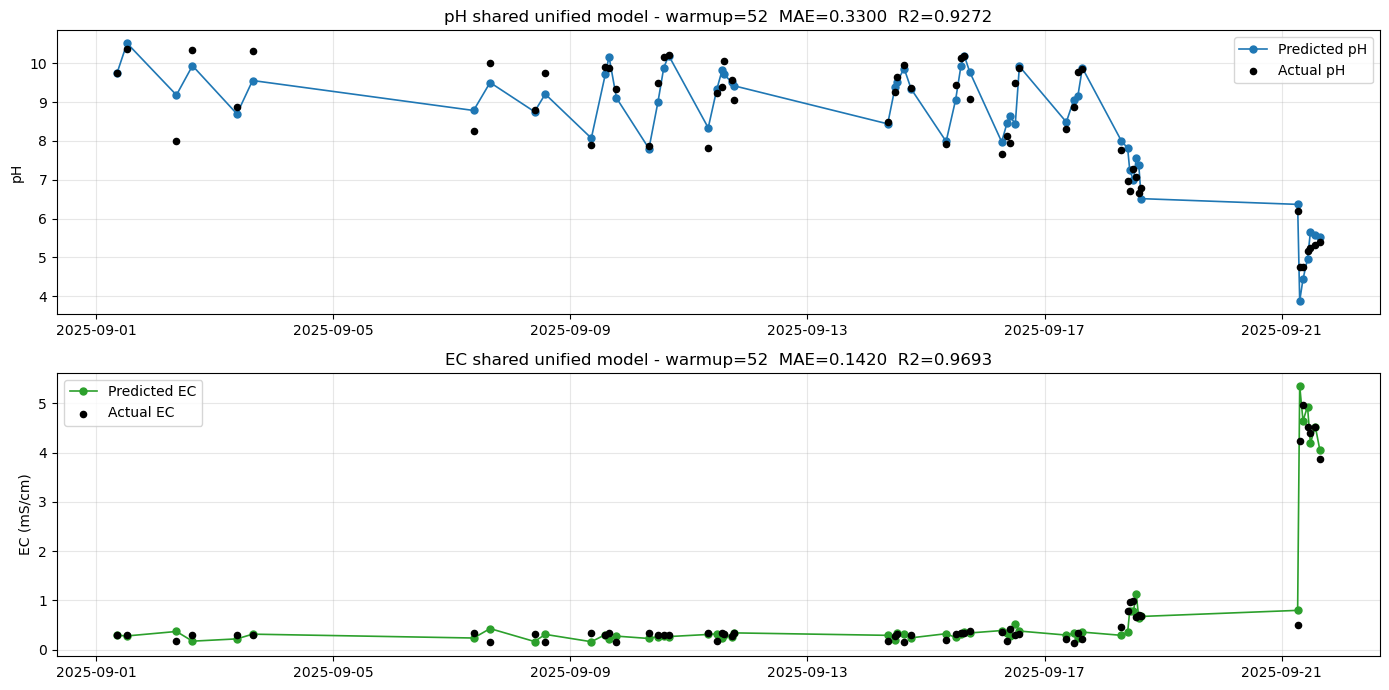

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

axes[0].plot(res_ph.index, res_ph['ph_pred'], 'o-', color='tab:blue', ms=5, lw=1.2, label='Predicted pH')
axes[0].scatter(ev_ph.index, ev_ph['ph_true'], color='black', s=20, zorder=5, label='Actual pH')
axes[0].set_ylabel('pH')
axes[0].set_title(f'pH shared unified model - warmup={SHARED_WARMUP}  MAE={m_ph["ph_mae"]:.4f}  R2={m_ph["ph_r2"]:.4f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(res_ec.index, res_ec['ec_pred'], 'o-', color='tab:green', ms=5, lw=1.2, label='Predicted EC')
axes[1].scatter(ev_ec.index, ev_ec['ec_true'], color='black', s=20, zorder=5, label='Actual EC')
axes[1].set_ylabel('EC (mS/cm)')
axes[1].set_title(f'EC shared unified model - warmup={SHARED_WARMUP}  MAE={m_ec["ec_mae"]:.4f}  R2={m_ec["ec_r2"]:.4f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## XGBoost Feature Importance

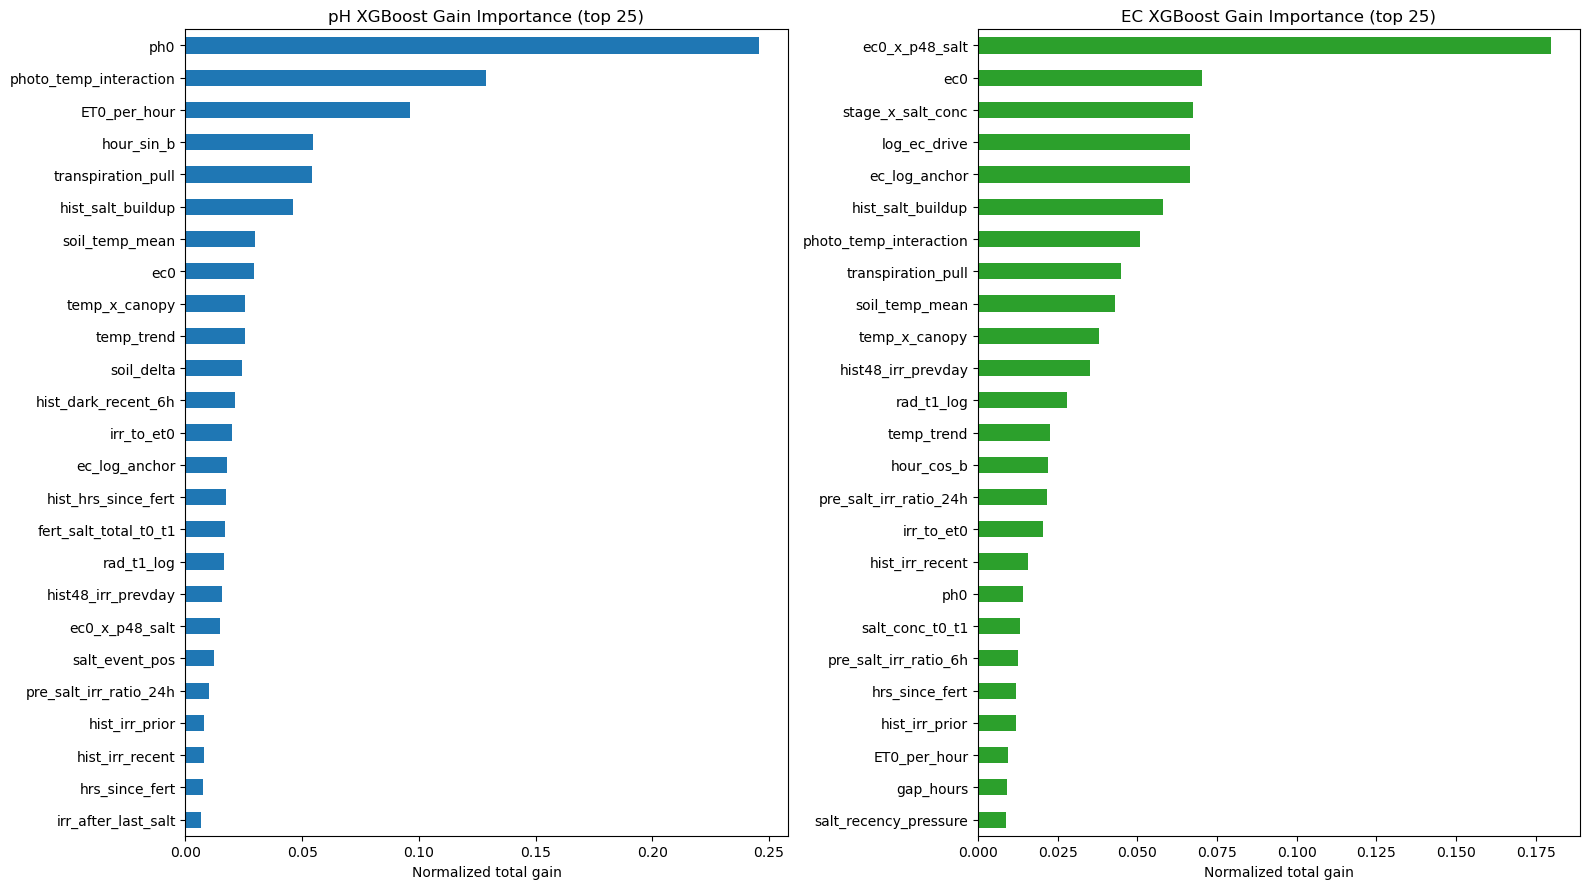

Feature-importance balance check


,view,top_feature,top1_share,top5_share
0,pH target trees,ph0,0.245602,0.579605
1,EC target trees,ec0_x_p48_salt,0.179842,0.450599


Target-specific importance is the fairer view for pH vs EC.


,global_xgb_total_gain,global_xgb_gain_importance,global_xgb_split_count,ph_xgb_total_gain,ph_xgb_gain_importance,ph_xgb_split_count,ec_xgb_total_gain,ec_xgb_gain_importance,ec_xgb_split_count,mean_target_xgb_gain_importance
ph0,2708.860550,0.202822,411,2673.900528,0.245602,327,34.960021,0.014161,84,0.129882
ec0_x_p48_salt,607.148377,0.045459,288,163.175496,0.014988,130,443.972881,0.179842,158,0.097415
photo_temp_interaction,1527.908923,0.114400,237,1402.499165,0.128822,140,125.409759,0.050800,97,0.089811
ET0_per_hour,1070.495624,0.080152,250,1047.012685,0.096170,186,23.482939,0.009512,64,0.052841
hist_salt_buildup,643.284476,0.048165,295,499.834791,0.045911,151,143.449685,0.058108,144,0.052009
ec0,490.657816,0.036737,336,317.371777,0.029151,174,173.286040,0.070194,162,0.049672
transpiration_pull,701.967109,0.052559,323,591.224534,0.054305,194,110.742575,0.044859,129,0.049582
ec_log_anchor,356.622716,0.026702,256,192.533024,0.017684,138,164.089692,0.066468,118,0.042076
stage_x_salt_conc,232.603817,0.017416,149,66.043998,0.006066,58,166.559819,0.067469,91,0.036768
soil_temp_mean,429.011908,0.032122,245,322.907282,0.029660,146,106.104626,0.042980,99,0.036320


In [8]:
# XGBoost feature importance for the shared multi-output model.
# XGBoost alternates target trees: even tree IDs are pH delta, odd tree IDs are EC log-delta.

def xgb_importance_by_target(shared_model, feature_cols):
    tree_df = shared_model['base'].get_booster().trees_to_dataframe()
    split_df = tree_df[tree_df['Feature'] != 'Leaf'].copy()
    split_df['target'] = np.where(split_df['Tree'] % 2 == 0, 'pH_delta', 'EC_log_delta')

    out = pd.DataFrame(index=feature_cols)
    global_gain = split_df.groupby('Feature')['Gain'].sum().reindex(feature_cols).fillna(0.0)
    global_split_count = split_df.groupby('Feature').size().reindex(feature_cols).fillna(0).astype(int)
    out['global_xgb_total_gain'] = global_gain
    out['global_xgb_gain_importance'] = global_gain / global_gain.sum() if global_gain.sum() else global_gain
    out['global_xgb_split_count'] = global_split_count

    for target_name, prefix in [('pH_delta', 'ph'), ('EC_log_delta', 'ec')]:
        g = split_df[split_df['target'] == target_name]
        total_gain = g.groupby('Feature')['Gain'].sum().reindex(feature_cols).fillna(0.0)
        split_count = g.groupby('Feature').size().reindex(feature_cols).fillna(0).astype(int)
        out[f'{prefix}_xgb_total_gain'] = total_gain
        out[f'{prefix}_xgb_gain_importance'] = total_gain / total_gain.sum() if total_gain.sum() else total_gain
        out[f'{prefix}_xgb_split_count'] = split_count

    out['mean_target_xgb_gain_importance'] = out[
        ['ph_xgb_gain_importance', 'ec_xgb_gain_importance']
    ].mean(axis=1)
    return out


xgb_target_imp = xgb_importance_by_target(shared_model, shared_feature_cols)
base_imp = xgb_target_imp['global_xgb_gain_importance'].sort_values()
ph_xgb_imp = xgb_target_imp['ph_xgb_gain_importance'].sort_values()
ec_xgb_imp = xgb_target_imp['ec_xgb_gain_importance'].sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 9))

ph_xgb_imp.tail(25).plot(kind='barh', ax=axes[0], color='tab:blue')
axes[0].set_title('pH XGBoost Gain Importance (top 25)')
axes[0].set_xlabel('Normalized total gain')

ec_xgb_imp.tail(25).plot(kind='barh', ax=axes[1], color='tab:green')
axes[1].set_title('EC XGBoost Gain Importance (top 25)')
axes[1].set_xlabel('Normalized total gain')

plt.tight_layout()
plt.show()

importance_balance = pd.DataFrame([
    {
        'view': 'pH target trees',
        'top_feature': xgb_target_imp['ph_xgb_gain_importance'].idxmax(),
        'top1_share': xgb_target_imp['ph_xgb_gain_importance'].max(),
        'top5_share': xgb_target_imp['ph_xgb_gain_importance'].sort_values(ascending=False).head(5).sum(),
    },
    {
        'view': 'EC target trees',
        'top_feature': xgb_target_imp['ec_xgb_gain_importance'].idxmax(),
        'top1_share': xgb_target_imp['ec_xgb_gain_importance'].max(),
        'top5_share': xgb_target_imp['ec_xgb_gain_importance'].sort_values(ascending=False).head(5).sum(),
    },
])

print('Feature-importance balance check')
display(importance_balance)

print('Target-specific importance is the fairer view for pH vs EC.')
display(xgb_target_imp.sort_values('mean_target_xgb_gain_importance', ascending=False).head(15))


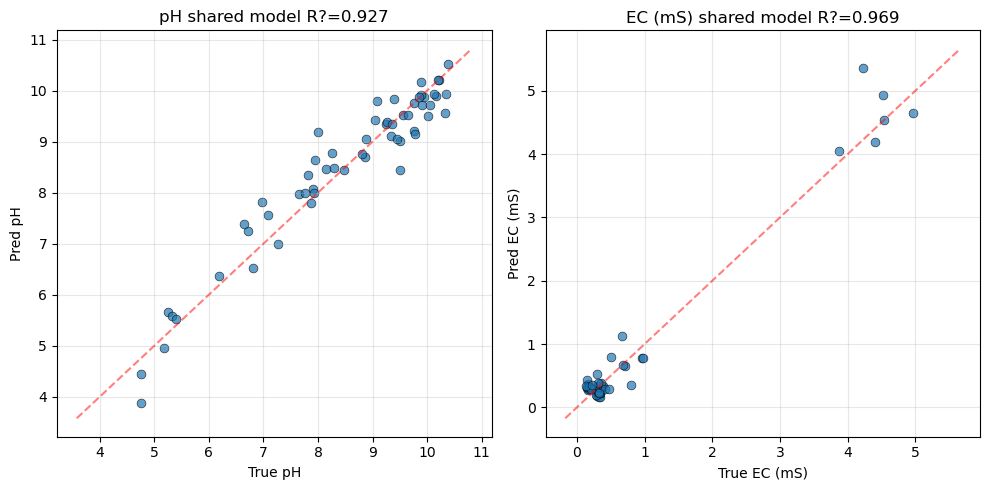

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, ev, name, tc, pc in [
    (axes[0], ev_ph, 'pH',      'ph_true', 'ph_pred'),
    (axes[1], ev_ec, 'EC (mS)', 'ec_true', 'ec_pred'),
]:
    t = ev[tc].values
    p = ev[pc].values
    ax.scatter(t, p, alpha=0.7, s=40, edgecolors='k', lw=0.5)
    lims = [min(t.min(), p.min()) - 0.3, max(t.max(), p.max()) + 0.3]
    ax.plot(lims, lims, 'r--', alpha=0.5)
    ax.set_xlabel(f'True {name}')
    ax.set_ylabel(f'Pred {name}')
    ax.set_title(f'{name} shared model R?={r2_score(t, p):.3f}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


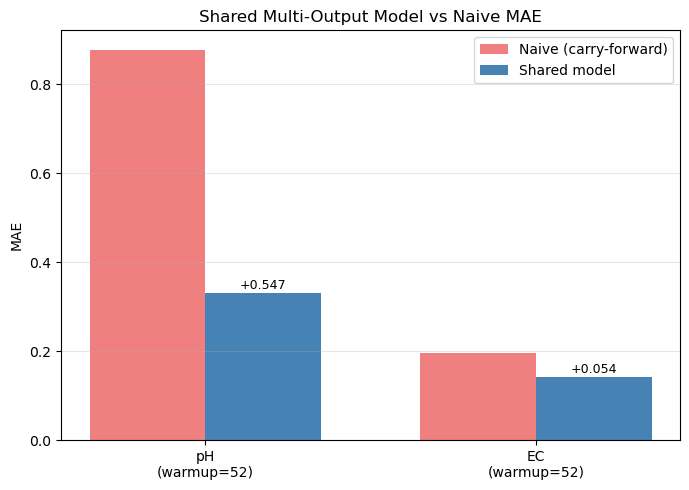

In [10]:
targets = ['pH', 'EC']
model_mae = [m_ph['ph_mae'], m_ec['ec_mae']]
naive_mae = [m_ph['ph_mae_naive'], m_ec['ec_mae_naive']]

x = np.arange(len(targets))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - width/2, naive_mae, width, label='Naive (carry-forward)', color='lightcoral')
ax.bar(x + width/2, model_mae, width, label='Shared model', color='steelblue')

for i, (m, n) in enumerate(zip(model_mae, naive_mae)):
    gain = n - m
    ax.text(i + width/2, m + 0.002, f'+{gain:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f'pH\n(warmup={SHARED_WARMUP})', f'EC\n(warmup={SHARED_WARMUP})'])
ax.set_ylabel('MAE')
ax.set_title('Shared Multi-Output Model vs Naive MAE')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


In [11]:
summary = pd.DataFrame([
    {'Target': 'pH', 'Warmup': SHARED_WARMUP, 'MAE': m_ph['ph_mae'], 'RMSE': m_ph['ph_rmse'],
     'Naive MAE': m_ph['ph_mae_naive'], 'Gain': m_ph['ph_gain_mae'], 'Gain %': 100.0 * m_ph['ph_gain_mae'] / m_ph['ph_mae_naive'], 'R2': m_ph['ph_r2'], 'N test': m_ph['n_test'],
     'Holdout MAE': ph_mae, 'Holdout R2': ph_r2},
    {'Target': 'EC', 'Warmup': SHARED_WARMUP, 'MAE': m_ec['ec_mae'], 'RMSE': m_ec['ec_rmse'],
     'Naive MAE': m_ec['ec_mae_naive'], 'Gain': m_ec['ec_gain_mae'], 'Gain %': 100.0 * m_ec['ec_gain_mae'] / m_ec['ec_mae_naive'], 'R2': m_ec['ec_r2'], 'N test': m_ec['n_test'],
     'Holdout MAE': ec_mae, 'Holdout R2': ec_r2},
]).set_index('Target')
print(summary.to_string())


        Warmup       MAE      RMSE  Naive MAE      Gain     Gain %        R2  N test  Holdout MAE  Holdout R2
Target                                                                                                       
pH          52  0.329962  0.429030   0.876842  0.546880  62.369231  0.927242      57     0.305993    0.918786
EC          52  0.142046  0.221789   0.196077  0.054031  27.556187  0.969298      57     0.130090    0.955368


## EC Warmup30 Stress Check

The cells below rerun the same unified model from warmup 30. Nothing changes except the evaluation start:
- same `shared_feature_cols`
- same XGBoost params
- same robust linear params
- same robust linear gate/blend
- same pH delta and EC log-delta target setup


In [12]:
def run_shared_walkforward_with_warmup(warmup):
    train_df = pd.DataFrame(_build_shared_rows(warmup)).set_index('timestamp').sort_index()
    model = _fit_shared_model(train_df)

    rows = []
    anchor = sensor_idx[warmup]
    retrain_count = 0

    for k in range(warmup, len(sensor_idx)):
        cur = sensor_idx[k]
        feats = get_features_shared(master_df, anchor, cur)
        if feats['gap_hours'] <= 0:
            raw, model_component = np.array([0.0, 0.0]), 'xgboost'
        else:
            raw, model_component = _predict_shared_raw_and_type(model, feats)

        ph_pred = feats['ph0'] + raw[0]
        ec_pred = max(0.0, (feats['ec0'] + EC_TARGET_SHIFT) * np.exp(raw[1]) - EC_TARGET_SHIFT)

        rows.append({
            'timestamp': cur,
            'gap_hours': feats['gap_hours'],
            'ph_true': float(master_df.loc[cur, 'ph']),
            'ph_pred': ph_pred,
            'ph_naive': feats['ph0'],
            'ec_true': float(master_df.loc[cur, 'ec_ms']),
            'ec_pred': ec_pred,
            'ec_naive': feats['ec0'],
            'n_train': len(train_df),
            'robust_linear_active': model_component == 'robust_linear',
            'model_component': model_component,
        })

        if k > warmup:
            new_rows = [_make_shared_row(k - 1, k)]
            for j, _, back, _ in _selected_shared_skip_pairs(k):
                new_rows.append(_make_shared_row(j, k, sensor_idx[k] + pd.Timedelta(microseconds=back)))
            train_df = pd.concat([train_df, pd.DataFrame(new_rows).set_index('timestamp')]).sort_index()
            model = _fit_shared_model(train_df)
            retrain_count += 1

        anchor = cur

    ev = pd.DataFrame(rows).set_index('timestamp')
    return model, ev, retrain_count


STRESS_WARMUP_EC = 30
stress_model, stress_ev, stress_retrains = run_shared_walkforward_with_warmup(STRESS_WARMUP_EC)
ev_ec_stress = stress_ev[['ec_true', 'ec_pred', 'ec_naive', 'gap_hours', 'n_train', 'robust_linear_active', 'model_component']].copy()
res_ec_stress = stress_ev[['ec_pred', 'gap_hours', 'n_train', 'robust_linear_active', 'model_component']].copy()

m_ec_stress = {
    'warmup': STRESS_WARMUP_EC,
    'target': 'ec',
    'ec_mae': float(mean_absolute_error(stress_ev['ec_true'], stress_ev['ec_pred'])),
    'ec_rmse': _rmse(stress_ev['ec_true'], stress_ev['ec_pred']),
    'ec_mae_naive': float(mean_absolute_error(stress_ev['ec_true'], stress_ev['ec_naive'])),
    'ec_gain_mae': float(mean_absolute_error(stress_ev['ec_true'], stress_ev['ec_naive']) - mean_absolute_error(stress_ev['ec_true'], stress_ev['ec_pred'])),
    'ec_r2': float(r2_score(stress_ev['ec_true'], stress_ev['ec_pred'])),
    'n_test': int(len(stress_ev)),
}

print(f'EC unified model stress check (warmup={STRESS_WARMUP_EC}): '
      f'MAE={m_ec_stress["ec_mae"]:.4f}  naive={m_ec_stress["ec_mae_naive"]:.4f}  '
      f'gain={m_ec_stress["ec_gain_mae"]:.4f}  R2={m_ec_stress["ec_r2"]:.4f}')



EC unified model stress check (warmup=30): MAE=0.1852  naive=0.2467  gain=0.0615  R2=0.9318


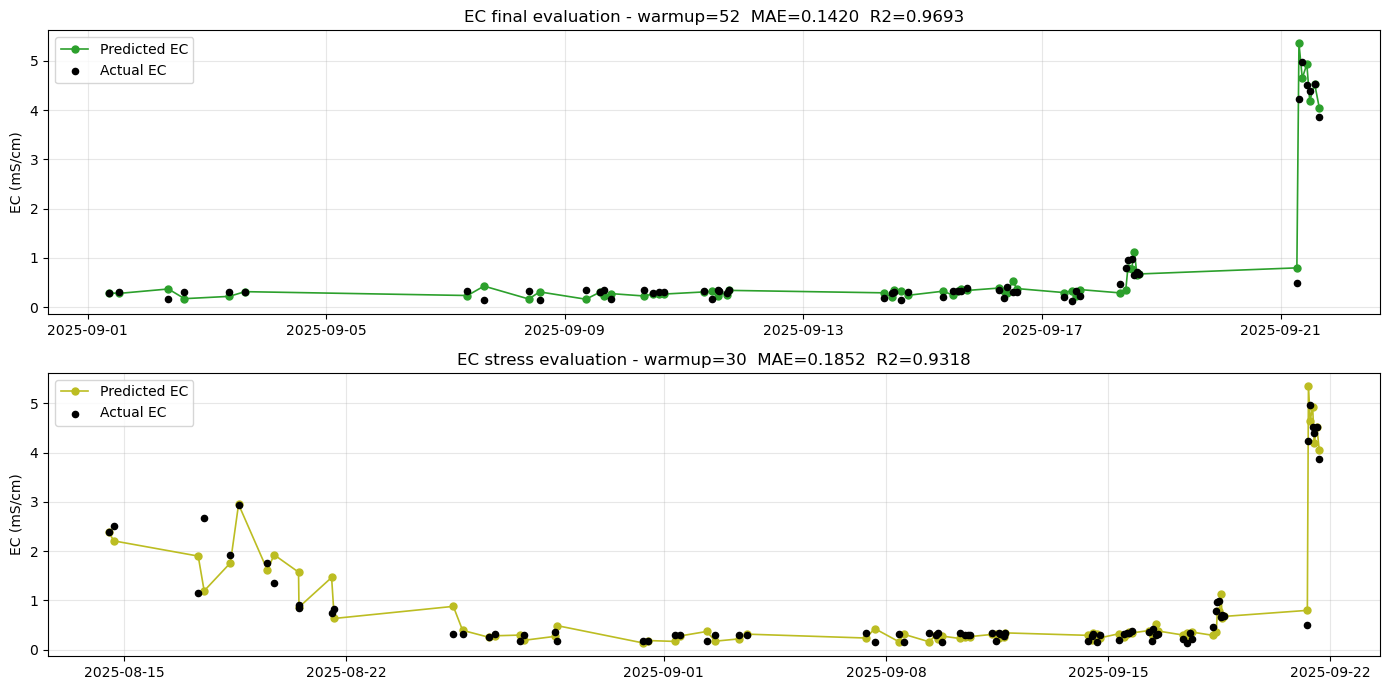

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

axes[0].plot(res_ec.index, res_ec['ec_pred'], 'o-', color='tab:green', ms=5, lw=1.2, label='Predicted EC')
axes[0].scatter(ev_ec.index, ev_ec['ec_true'], color='black', s=20, zorder=5, label='Actual EC')
axes[0].set_ylabel('EC (mS/cm)')
axes[0].set_title(f'EC final evaluation - warmup={SHARED_WARMUP}  MAE={m_ec["ec_mae"]:.4f}  R2={m_ec["ec_r2"]:.4f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(res_ec_stress.index, res_ec_stress['ec_pred'], 'o-', color='tab:olive', ms=5, lw=1.2, label='Predicted EC')
axes[1].scatter(ev_ec_stress.index, ev_ec_stress['ec_true'], color='black', s=20, zorder=5, label='Actual EC')
axes[1].set_ylabel('EC (mS/cm)')
axes[1].set_title(f'EC stress evaluation - warmup={STRESS_WARMUP_EC}  MAE={m_ec_stress["ec_mae"]:.4f}  R2={m_ec_stress["ec_r2"]:.4f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [14]:
unified_summary = summary.copy()
unified_stress_row = pd.DataFrame([
    {
        'Target': 'EC stress',
        'Warmup': STRESS_WARMUP_EC,
        'MAE': m_ec_stress['ec_mae'],
        'RMSE': m_ec_stress['ec_rmse'],
        'Naive MAE': m_ec_stress['ec_mae_naive'],
        'Gain': m_ec_stress['ec_gain_mae'],
        'Gain %': 100.0 * m_ec_stress['ec_gain_mae'] / m_ec_stress['ec_mae_naive'],
        'R2': m_ec_stress['ec_r2'],
        'N test': m_ec_stress['n_test'],
        'Holdout MAE': np.nan,
        'Holdout R2': np.nan,
    }
]).set_index('Target')

unified_summary = pd.concat([unified_summary, unified_stress_row])
print(unified_summary.to_string())


           Warmup       MAE      RMSE  Naive MAE      Gain     Gain %        R2  N test  Holdout MAE  Holdout R2
Target                                                                                                          
pH             52  0.329962  0.429030   0.876842  0.546880  62.369231  0.927242      57     0.305993    0.918786
EC             52  0.142046  0.221789   0.196077  0.054031  27.556187  0.969298      57     0.130090    0.955368
EC stress      30  0.185232  0.308662   0.246735  0.061503  24.926580  0.931784      79          NaN         NaN


## Exports

In [15]:
import os
os.makedirs('exports', exist_ok=True)

EXPORT_PREFIX = 'v8_variant_e_ratio_48h'

ev_ph[['ph_true', 'ph_pred', 'ph_naive', 'gap_hours', 'n_train']].to_csv(f'exports/{EXPORT_PREFIX}_eval_ph.csv', index_label='timestamp')
ev_ec[['ec_true', 'ec_pred', 'ec_naive', 'gap_hours', 'n_train']].to_csv(f'exports/{EXPORT_PREFIX}_eval_ec.csv', index_label='timestamp')
res_ph[['ph_pred', 'gap_hours', 'n_train']].to_csv(f'exports/{EXPORT_PREFIX}_pred_ph.csv', index_label='timestamp')
res_ec[['ec_pred', 'gap_hours', 'n_train']].to_csv(f'exports/{EXPORT_PREFIX}_pred_ec.csv', index_label='timestamp')
hdf[['j', 'k', 't0', 't1', 'gap_h', 'ph0', 'ph_true', 'ph_pred', 'ph_naive', 'ec0', 'ec_true', 'ec_pred', 'ec_naive', 'ph_err', 'ec_err', 'ph_naive_err', 'ec_naive_err']].to_csv(f'exports/{EXPORT_PREFIX}_holdout_detail.csv', index=False)
summary.to_csv(f'exports/{EXPORT_PREFIX}_summary.csv')
unified_summary.to_csv(f'exports/{EXPORT_PREFIX}_summary_with_ec_warmup30.csv')
ev_ec_stress[['ec_true', 'ec_pred', 'ec_naive', 'gap_hours', 'n_train']].to_csv(f'exports/{EXPORT_PREFIX}_eval_ec_warmup30.csv', index_label='timestamp')
res_ec_stress[['ec_pred', 'gap_hours', 'n_train']].to_csv(f'exports/{EXPORT_PREFIX}_pred_ec_warmup30.csv', index_label='timestamp')

base_imp.sort_values(ascending=False).to_csv(f'exports/{EXPORT_PREFIX}_fi_shared_xgb.csv', header=['importance'])
xgb_target_imp.sort_values('global_xgb_gain_importance', ascending=False)[['ph_xgb_gain_importance', 'ec_xgb_gain_importance']].to_csv(
    f'exports/{EXPORT_PREFIX}_fi_xgb_by_target.csv'
)

print(f'{EXPORT_PREFIX} exports written to ./exports')
print(f'  summary rows: {len(unified_summary)}')
print(f'  shared features: {len(shared_feature_cols)}')
print(f'  warmup52 eval rows: {len(ev_ec)}')
print(f'  EC warmup30 eval rows: {len(ev_ec_stress)}')
print(f'  holdout rows: {len(hdf)}')


v8_variant_e_ratio_48h exports written to ./exports
  summary rows: 3
  shared features: 37
  warmup52 eval rows: 57
  EC warmup30 eval rows: 79
  holdout rows: 44


## Save Model

In [16]:
import joblib, json, os
from datetime import datetime

os.makedirs('saved_model', exist_ok=True)

# 1. Save the model dict (XGBRegressor + HuberRegressor pipeline inside)
joblib.dump(shared_model, 'saved_model/v8_shared_model.joblib')

# 2. Save the feature list and all constants needed at inference time
model_meta = {
    'saved_at':                  datetime.now().isoformat(),
    'feature_cols':              shared_feature_cols,
    'EC_TARGET_SHIFT':           EC_TARGET_SHIFT,
    'ROBUST_LINEAR_BLEND_PH':    ROBUST_LINEAR_BLEND_PH,
    'ROBUST_LINEAR_BLEND_EC':    ROBUST_LINEAR_BLEND_EC,
    'ROBUST_LINEAR_GATE_MAX_GAP_H': ROBUST_LINEAR_GATE_MAX_GAP_H,
    'SHARED_SCALE_TARGETS':      SHARED_SCALE_TARGETS,
    'n_train':                   shared_model['n_train'],
}
with open('saved_model/v8_model_meta.json', 'w') as f:
    json.dump(model_meta, f, indent=2)

print('Model saved to saved_model/')
print(f"  v8_shared_model.joblib  ({os.path.getsize('saved_model/v8_shared_model.joblib') / 1e6:.1f} MB)")
print(f"  v8_model_meta.json")
print(f"  features: {len(shared_feature_cols)}")
print(f"  trained on {shared_model['n_train']} rows")

Model saved to saved_model/
  v8_shared_model.joblib  (1.9 MB)
  v8_model_meta.json
  features: 37
  trained on 319 rows
